# Characterizing Network Traffic with Programmable Dataplanes

MAWI Working Group trace `201302011400.dump`, can be downloaded [here](http://mawi.nezu.wide.ad.jp/mawi/samplepoint-F/2013/201302011400.dump.gz).

This notebook requires the `201302011400.dump` and `output_with_features.pcap` to be found in the `data` folder. For informations on how to obtain the `output_with_features.pcap` file, look at the project `README.MD`

This notebook covers:
- **Task I**: Software-based traffic characterization (Python / Scapy)
- **Task II**: In-network feature extraction (P4 on BMV2)
- **Task III**: Comparison and discussion

In [1]:
P4_PCAP = "data/output_with_features.pcap"
DATA_PATH = "data/201302011400.dump"
N_PACKETS = 100_000

In [2]:
import sys
import warnings

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scapy.utils import rdpcap

from parser import parse_packets_into_packet_data, flow_analysis
from task2 import read_pcap_features

%matplotlib inline
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

---

## Task I
Results are split by protocol: **ALL** traffic, **TCP** only, and **UDP** only.

In [3]:
raw_packets = rdpcap(DATA_PATH, count=N_PACKETS)

In [4]:
data = parse_packets_into_packet_data(raw_packets)

In [5]:
tcp = data.tcp_packet_data
udp = data.udp_packet_data
all_data = data.all_packet_data

In [6]:
splits = {"ALL": all_data, "TCP": tcp, "UDP": udp}
t1_sizes = {name: pd.sizes for name, pd in splits.items()}

t1_iats = {}
for name, pd in splits.items():
    ts = pd.timestamps
    t1_iats[name] = [
        ts[i + 1] - ts[i] for i in range(len(ts) - 1) if ts[i + 1] - ts[i] > 0
    ]

t1_durations = {}
t1_throughputs = {}
for name, pd in splits.items():
    d, th = flow_analysis(pd.flows)
    t1_durations[name] = [x for x in d if x > 0]
    t1_throughputs[name] = [x for x in th if x > 0]

In [7]:
f"Packets: {len(all_data.sizes):,} (TCP: {len(tcp.sizes):,}, UDP: {len(udp.sizes):,})"

'Packets: 100,000 (TCP: 83,446, UDP: 9,236)'

In [8]:
f"Flows: {len(all_data.flows):,} (TCP: {len(tcp.flows):,}, UDP: {len(udp.flows):,})"

'Flows: 9,644 (TCP: 6,615, UDP: 3,029)'

### Packet Size Distribution

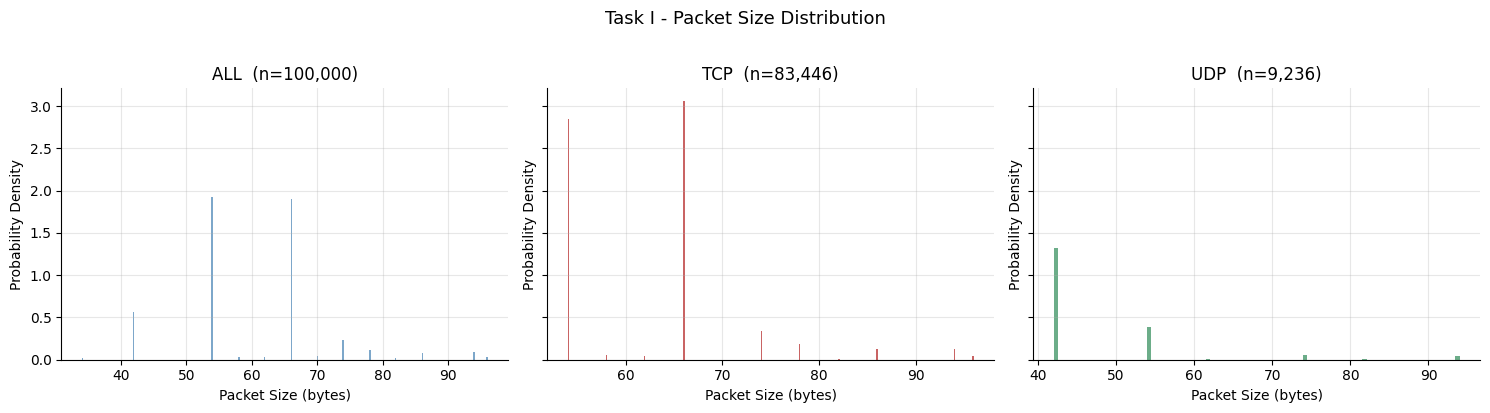

In [9]:
COLORS = ["steelblue", "firebrick", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, sizes), color in zip(axes, t1_sizes.items(), COLORS):
    n_bins = max(int(np.sqrt(len(sizes))), 10)
    ax.hist(sizes, bins=n_bins, density=True, alpha=0.7, color=color)
    ax.set_title(f"{name}  (n={len(sizes):,})")
    ax.set_xlabel("Packet Size (bytes)")
    ax.set_ylabel("Probability Density")
fig.suptitle("Task I - Packet Size Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Inter-Arrival Time (IAT) Distribution

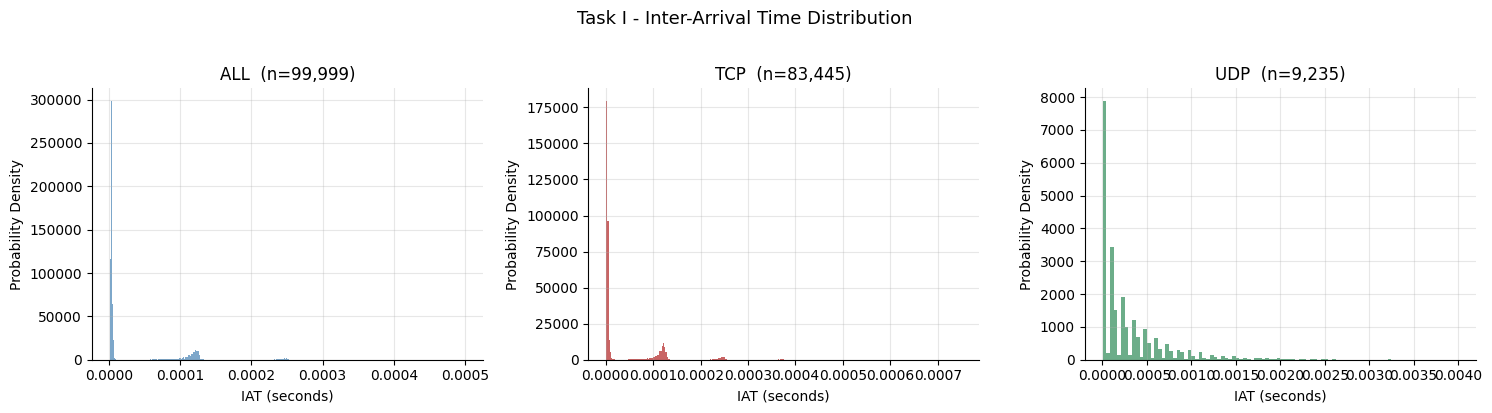

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, iats), color in zip(axes, t1_iats.items(), COLORS):
    n_bins = max(int(np.sqrt(len(iats))), 10)
    ax.hist(iats, bins=n_bins, density=True, alpha=0.7, color=color)
    ax.set_title(f"{name}  (n={len(iats):,})")
    ax.set_xlabel("IAT (seconds)")
    ax.set_ylabel("Probability Density")
fig.suptitle("Task I - Inter-Arrival Time Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Flow Duration Distribution

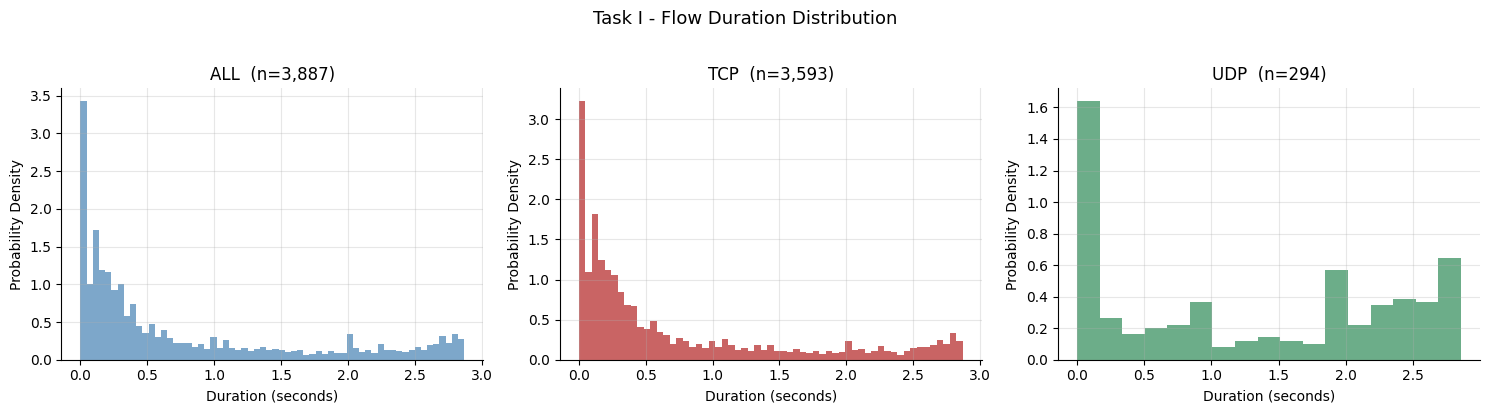

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, durs), color in zip(axes, t1_durations.items(), COLORS):
    n_bins = max(int(np.sqrt(len(durs))), 10)
    ax.hist(durs, bins=n_bins, density=True, alpha=0.7, color=color)
    ax.set_title(f"{name}  (n={len(durs):,})")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Probability Density")
fig.suptitle("Task I - Flow Duration Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Flow Throughput Distribution with Statistical Fitting

An **Inverse Gaussian** distribution is fitted to the throughput data.
Initially, an exploratory phase with multiple distribution fits was done, removed to improve code since the inverse gaussian performed significantly better both in the K-S test and visually.
Goodness of fit is evaluated with the Kolmogorov–Smirnov test.

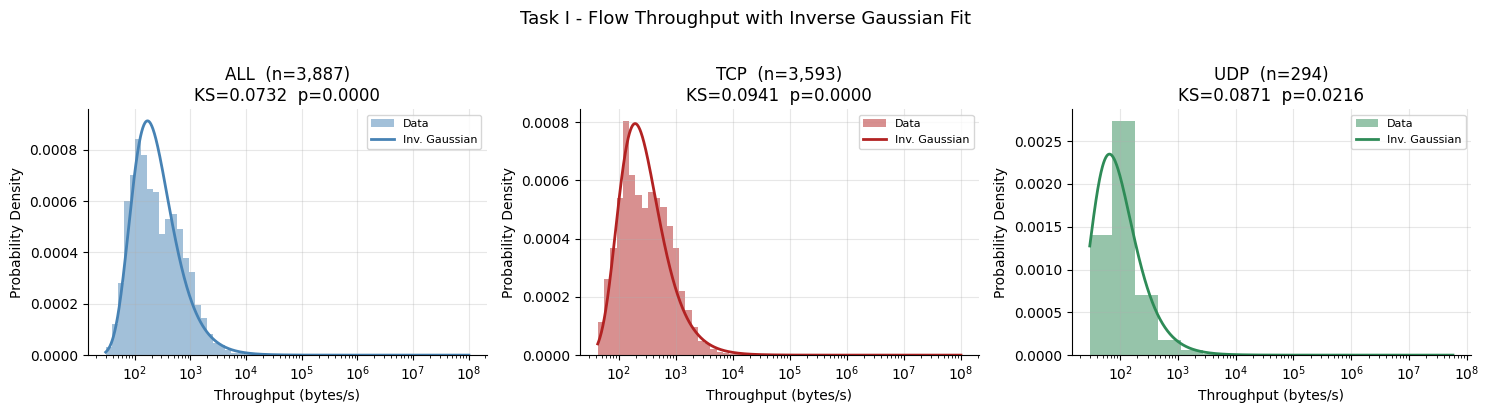

KS test results (Inverse Gaussian fit):
Split      KS Statistic      p-value
--------------------------------------
ALL               0.0732        0.0000
TCP               0.0941        0.0000
UDP               0.0871        0.0216


In [12]:
def fit_throughput(ax, throughputs, label, color="steelblue"):
    thr = np.array([t for t in throughputs if t > 0])
    log_min, log_max = np.log10(thr.min()), np.log10(thr.max())
    n_bins = max(int(np.sqrt(len(thr))), 10)
    bins = np.logspace(log_min, log_max, n_bins)
    ax.hist(thr, bins=bins, density=True, alpha=0.5, color=color, label="Data")
    params = stats.invgauss.fit(thr, floc=0)
    x = np.logspace(log_min, log_max, 1000)
    ax.plot(
        x,
        stats.invgauss.pdf(x, *params),
        linewidth=2,
        color=color,
        label="Inv. Gaussian",
    )
    ks_stat, p_val = stats.kstest(thr, stats.invgauss.cdf, args=params)
    ax.set_xscale("log")
    ax.set_xlabel("Throughput (bytes/s)")
    ax.set_ylabel("Probability Density")
    ax.set_title(f"{label}  (n={len(thr):,})\nKS={ks_stat:.4f}  p={p_val:.4f}")
    ax.legend(fontsize=8)
    return ks_stat, p_val


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t1_ks = {}
for ax, (name, thr), color in zip(axes, t1_throughputs.items(), COLORS):
    ks, p = fit_throughput(ax, thr, name, color)
    t1_ks[name] = (ks, p)
fig.suptitle("Task I - Flow Throughput with Inverse Gaussian Fit", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("KS test results (Inverse Gaussian fit):")
print(f"{'Split':<8} {'KS Statistic':>14} {'p-value':>12}")
print("-" * 38)
for name, (ks, p) in t1_ks.items():
    print(f"{name:<8}  {ks:>14.4f}  {p:>12.4f}")

---

## Task II - Network Feature Extraction (P4)

A P4 program running on BMV2 appends a 14-byte features_t header to every TCP/UDP packet:

```
features_t { pkt_size [32 bits] | iat [48 bits] | flow_idx [32 bits] }
```

- **Packet-level features** (size, IAT): parsed from the features_t header in the output PCAP;
- **Flow-level features** (duration, throughput): reconstructed from the PCAP by grouping packets on flow_idx.

IAT and duration are measured at replay speed (--multiplier=0.01),

In [13]:
print(f"Loading P4 output from {P4_PCAP} ...")
t2_sizes, t2_iats_raw, t2_flows_raw = read_pcap_features(P4_PCAP)

# The first packet's IAT equals the switch uptime (reg_last_timestamp initialized to 0).
# Filter out any IAT above 60 s to remove that (possible) outlier.
t2_iats = [x for x in t2_iats_raw if 0 < x < 60]

t2_durations = []
t2_throughputs = []
for f in t2_flows_raw.values():
    dur = f["last_ts"] - f["first_ts"]
    if dur > 0:
        t2_durations.append(dur)
        t2_throughputs.append(f["byte_count"] / dur)

print(f"Packets with features: {len(t2_sizes):,}")
print(f"Active flows: {len(t2_flows_raw):,}")
print(
    f"IAT samples (filtered): {len(t2_iats):,}  ({len(t2_iats_raw) - len(t2_iats)} outlier(s) removed)"
)
print(f"Mean packet size: {np.mean(t2_sizes):.1f} bytes")
print(f"Mean IAT: {np.mean(t2_iats):.4f} s")
print(f"Mean flow duration: {np.mean(t2_durations):.3f} s")
print(f"Mean throughput: {np.mean(t2_throughputs):.1f} bytes/s")

Loading P4 output from data/output_with_features.pcap ...
Packets with features: 90,561
Active flows: 8,599
IAT samples (filtered): 90,559  (2 outlier(s) removed)
Mean packet size: 60.4 bytes
Mean IAT: 0.0029 s
Mean flow duration: 85.232 s
Mean throughput: 9323.3 bytes/s


### Packet Size, IAT, Flow Duration, Flow Throughput

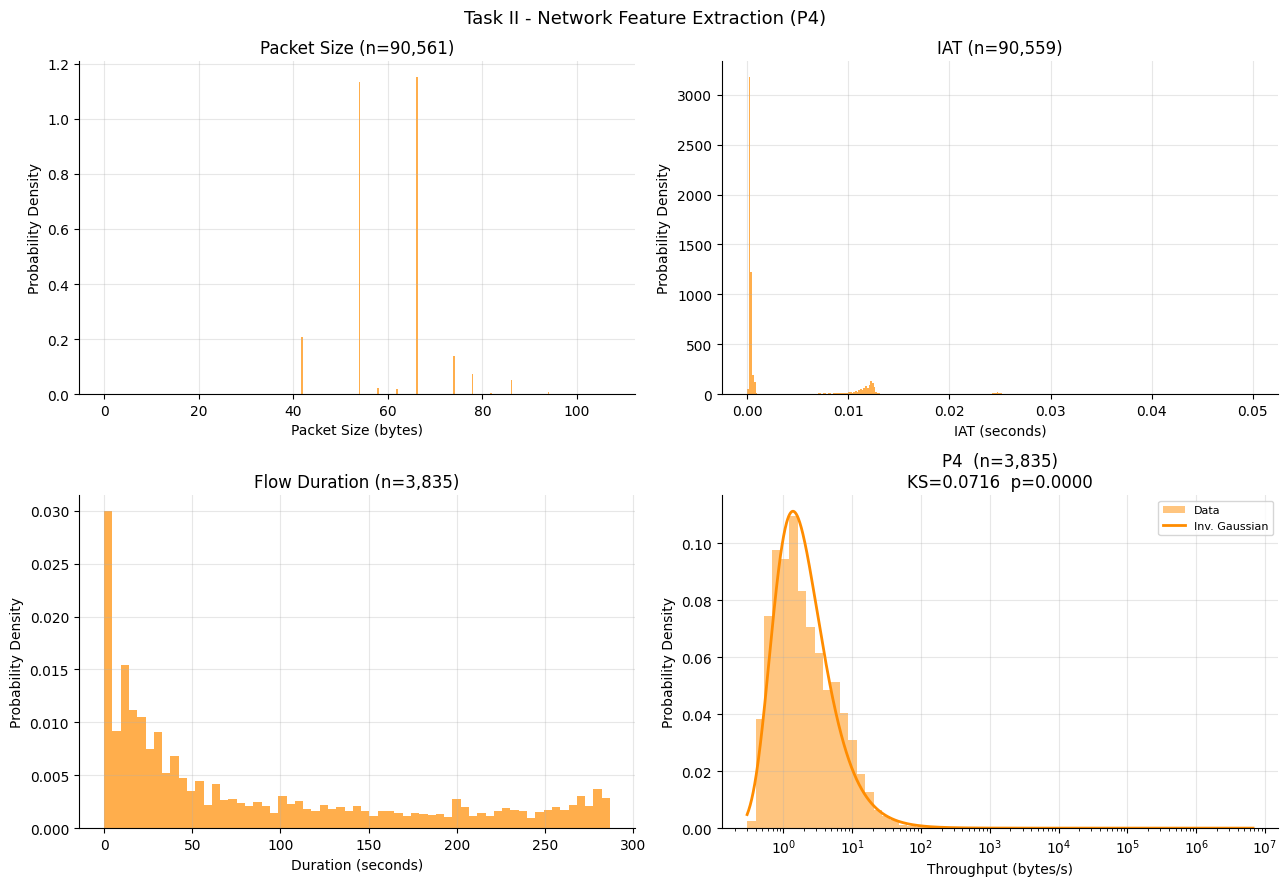

KS test (Inverse Gaussian) - P4 throughput:  KS=0.0716,  p=0.0000


In [14]:
P4_COLOR = "darkorange"
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Packet size
ax = axes[0, 0]
n_bins = max(int(np.sqrt(len(t2_sizes))), 10)
ax.hist(t2_sizes, bins=n_bins, density=True, alpha=0.7, color=P4_COLOR)
ax.set_xlabel("Packet Size (bytes)")
ax.set_ylabel("Probability Density")
ax.set_title(f"Packet Size (n={len(t2_sizes):,})")

# IAT
ax = axes[0, 1]
n_bins = max(int(np.sqrt(len(t2_iats))), 10)
ax.hist(t2_iats, bins=n_bins, density=True, alpha=0.7, color=P4_COLOR)
ax.set_xlabel("IAT (seconds)")
ax.set_ylabel("Probability Density")
ax.set_title(f"IAT (n={len(t2_iats):,})")

# Flow duration
ax = axes[1, 0]
n_bins = max(int(np.sqrt(len(t2_durations))), 10)
ax.hist(t2_durations, bins=n_bins, density=True, alpha=0.7, color=P4_COLOR)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Probability Density")
ax.set_title(f"Flow Duration (n={len(t2_durations):,})")

ax = axes[1, 1]
ks_t2, p_t2 = fit_throughput(ax, t2_throughputs, "P4", P4_COLOR)

fig.suptitle("Task II - Network Feature Extraction (P4)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"KS test (Inverse Gaussian) - P4 throughput:  KS={ks_t2:.4f},  p={p_t2:.4f}")

---

## Task III — Comparison

Feature distributions from Task I (ALL traffic, blue) and Task II (P4, orange) overlaid.

> IAT and duration scales differ because Task I uses original PCAP timestamps while Task II uses replay timestamps at 0.01× speed.
> To graphically compare them, we will divide task 2 iat and duration by 100.

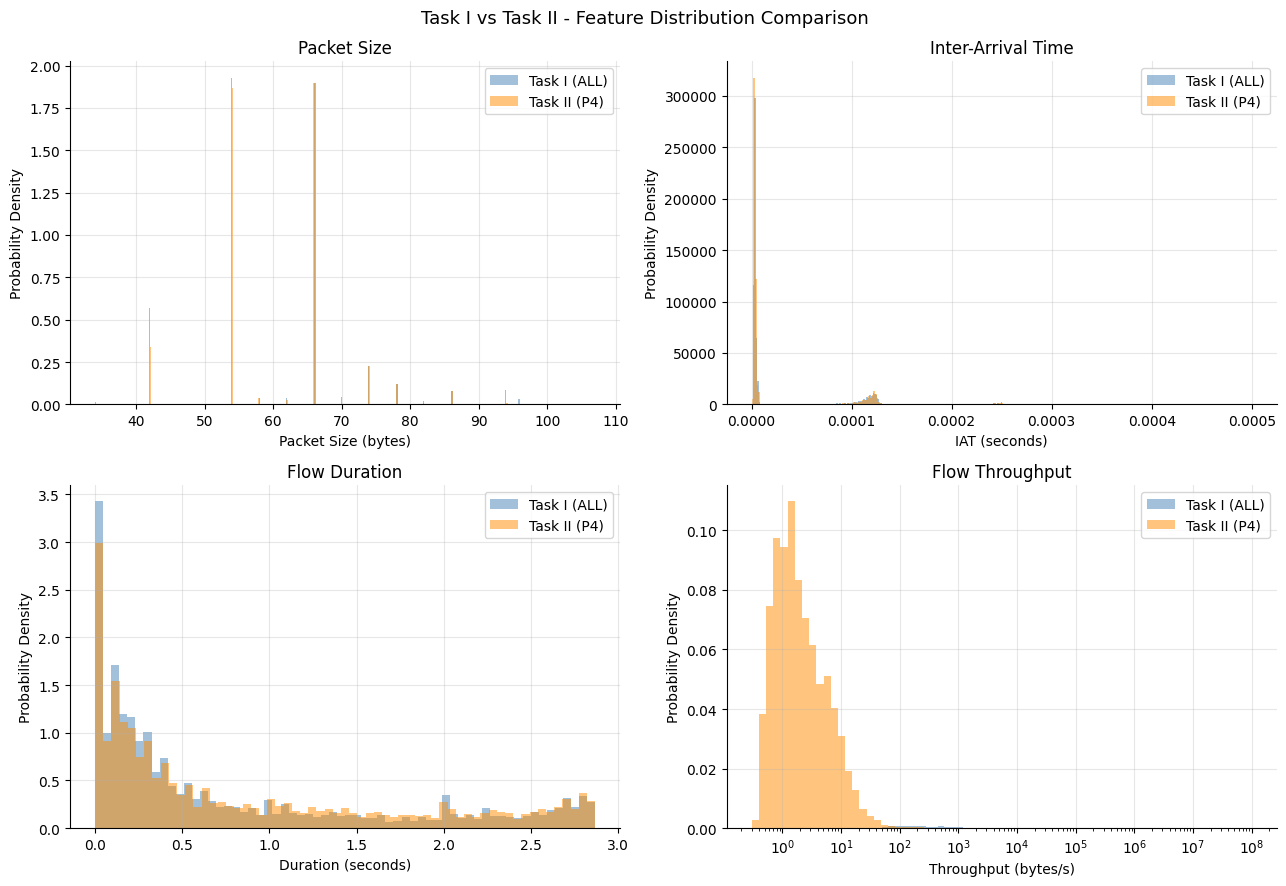

In [15]:
T1_COLOR, T2_COLOR = "steelblue", "darkorange"


def overlay(ax, d1, d2, xlabel, title, log_x=False):
    color_list = [(d1, "Task I (ALL)", T1_COLOR), (d2, "Task II (P4)", T2_COLOR)]
    for dataset, label, color in color_list:
        dataset = [x for x in dataset if x > 0]
        if not dataset:
            continue
        n_bins = max(int(np.sqrt(len(dataset))), 10)
        if log_x:
            bins = np.logspace(np.log10(min(dataset)), np.log10(max(dataset)), n_bins)
        else:
            bins = n_bins
        ax.hist(dataset, bins=bins, density=True, alpha=0.5, label=label, color=color)
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability Density")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
overlay(axes[0, 0], t1_sizes["ALL"], t2_sizes, "Packet Size (bytes)", "Packet Size")
overlay(
    axes[0, 1],
    t1_iats["ALL"],
    [x / 100 for x in t2_iats],
    "IAT (seconds)",
    "Inter-Arrival Time",
)
overlay(
    axes[1, 0],
    t1_durations["ALL"],
    [x / 100 for x in t2_durations],
    "Duration (seconds)",
    "Flow Duration",
)
overlay(
    axes[1, 1],
    t1_throughputs["ALL"],
    t2_throughputs,
    "Throughput (bytes/s)",
    "Flow Throughput",
    log_x=True,
)

fig.suptitle("Task I vs Task II - Feature Distribution Comparison", fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
rows = [
    ("Packets analysed", f"{len(t1_sizes['ALL']):,}", f"{len(t2_sizes):,}"),
    ("Flows", f"{len(all_data.flows):,}", f"{len(t2_flows_raw):,}"),
    (
        "Mean pkt size (B)",
        f"{np.mean(t1_sizes['ALL']):.1f}",
        f"{np.mean(t2_sizes):.1f}",
    ),
    ("Mean IAT (s)", f"{np.mean(t1_iats['ALL']):.5f}", f"{np.mean(t2_iats):.5f}"),
    (
        "Mean duration (s)",
        f"{np.mean(t1_durations['ALL']):.3f}",
        f"{np.mean(t2_durations):.3f}",
    ),
    ("Throughput KS", f"{t1_ks['ALL'][0]:.4f}", f"{ks_t2:.4f}"),
    ("Throughput p-val", f"{t1_ks['ALL'][1]:.4f}", f"{p_t2:.4f}"),
]
w = [22, 18, 18]
header = ["Metric", "Task I (ALL)", "Task II (P4)"]
print("  ".join(h.ljust(c) for h, c in zip(header, w)))
print("-" * (sum(w) + 4))
for row in rows:
    print("  ".join(v.ljust(c) for v, c in zip(row, w)))

Metric                  Task I (ALL)        Task II (P4)      
--------------------------------------------------------------
Packets analysed        100,000             90,561            
Flows                   9,644               8,599             
Mean pkt size (B)       60.3                60.4              
Mean IAT (s)            0.00003             0.00286           
Mean duration (s)       0.773               85.232            
Throughput KS           0.0732              0.0716            
Throughput p-val        0.0000              0.0000            


---

## Discussion

This project introduced a new way of thinking traffic analysis, leveraging the p4 programming language as a valid tool to utilize for this purpose.

---

### Accuracy
Accuracy for the two tasks can be analyzed in two groups:
1. packet data: accuracy for fields that are independent of flow (e.g. size) is similar, with no accuracy loss detected. In the case of packet being truncated, taking size as the field to analyze, we could have loss of accuracy in the standalone python script while in the combination of python + p4 we would have a more precise measurement thanks to the information provided in the added headers;
2. flow data: the approach for this project introduces some simplification that results in accuracy loss (e.g. hash collision will merge some flows together) but no accuracy loss is foreseen provided a robust implementation in the p4 code. It is important to consider that there would be accuracy loss in the case of per-flow IAT: right now the code operates under the assumption that IAT is global, with per-flow IAT the p4 code would lose accuracy.
A point that would require further study is the accuracy of timestamp: intuitively, comparing the tcpdump and p4 approach, ingress_global_timestamp should be more accurate.

---

### Overhead

The overhead can be observed looking at various hardware characteristics:
1. Disk: The standalone python script requires the traffic to be stored (and possibly moved);
2. CPU/Memory: The standalone python script does not require special hardware, but needs some software optimization (e.g. not loading in bulk all the packets);
3. Bandwidth: 14 bytes are added at every packet, resulting in an additional 1.4 Megabyte sent every 100000 packets. This will obviously result in increased processing time, increased latency, and decrease in throughput. The additional overhead in a critical component of the network may be considered unreasonable and avoided.

P4 biggest advantage is that it may do all the processing with zero CPU involvement (e.g. leveraging ASIC); when dealing with high traffic, this may be incredibly advantageous and cheaper.

---

### Scalability

The python standalone approach is not easily scalable: traffic dump must be saved, moved, and analyzed (possibly in a centralized data center) for each network device.
The p4 approach is instead scalable:
1. The code is easily compiled for specific devices and does not need significant rewrites between components;
2. Code is easily distributed to the hardware, does not require centralization.
---

### Ease of Implementation
In this brief introduction I'll list some issues encountered with the use of p4:
1. Lack of lsp server: writing code for p4 is tedious if done without formal training, caused by the lack of hints (e.g. what field can be accessed in a given structure);
2. Setup to test the code is not intuitive and can easily break;
3. toolchain is lacking and compiler needs to output more informative warning and error messages.
This is all to say that this language would benefit a lot from better online/offline resources and a better tool-chain since, while new, it can be compared to languages that were created in the same years with much more work done on the tool-chain.

The p4 tool-chain is still immature, as such it increases complexity introducing it in a project. Compared to python:
 1. no dynamic memory;
 2. limited operations possible (loops, arithmetic);
 3. does not have the python ecosystem of scientific libraries.
Errors in the p4 program can also corrupt traffic and may be harder to diagnose.

---

### Conclusion

Python is an easy but non-scalable approach, good for exploratory analysis and integration with ecosystem/ai approaches. The P4 approach is instead complex but can scale easily, providing real-time monitoring and processing of much more data at cheaper (components) price than the alternative could offer.